In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("osamaaslam86004/greyscale-synthetic-font-digits-blanaced")

print("Path to dataset files:", path)

100%|██████████| 49.9M/49.9M [00:00<00:00, 136MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/versions/1


In [2]:
import os
import shutil
from PIL import Image

# Install Pillow if not already installed
!pip install Pillow


### Moving dataset to `/content/`

In [3]:
# List contents of the downloaded dataset path
print(f"Contents of {path}:\n{os.listdir(path)}")

source_dir = path
destination_dir = "/content/"

# Get all items (files and directories) in the source directory
items = os.listdir(source_dir)

for item in items:
    source_item_path = os.path.join(source_dir, item)
    destination_item_path = os.path.join(destination_dir, item)
    if os.path.isdir(source_item_path):
        shutil.move(source_item_path, destination_item_path)
    else:
        shutil.move(source_item_path, destination_item_path)

print(f"\nMoved contents from {source_dir} to {destination_dir}")

# Verify contents in /content/
print(f"Contents of {destination_dir}:\n{os.listdir(destination_dir)}")

Contents of /root/.cache/kagglehub/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/versions/1:
['greyscale_synthetic_digits']

Moved contents from /root/.cache/kagglehub/datasets/osamaaslam86004/greyscale-synthetic-font-digits-blanaced/versions/1 to /content/
Contents of /content/:
['.config', 'greyscale_synthetic_digits', 'sample_data']


### Analyzing image properties

In [4]:
image_files = []
for root, _, files in os.walk("/content/greyscale_synthetic_digits"):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')):
            image_files.append(os.path.join(root, file))

if not image_files:
    print("No image files found in /content/")
else:
    # Take the first image to inspect format and channels
    first_image_path = image_files[0]
    img = Image.open(first_image_path)
    print(f"Example image: {first_image_path}")
    print(f"Image format: {img.format}")
    print(f"Image mode (channels): {img.mode}") # 'RGB', 'L' (grayscale), etc.

    # Check dimensions
    dimensions = {}
    consistent_dimensions = True
    first_width, first_height = img.size

    for img_path in image_files:
        try:
            with Image.open(img_path) as current_img:
                current_width, current_height = current_img.size
                if (current_width, current_height) not in dimensions:
                    dimensions[(current_width, current_height)] = 0
                dimensions[(current_width, current_height)] += 1

                if (current_width, current_height) != (first_width, first_height):
                    consistent_dimensions = False
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")

    print("\nDimension summary:")
    for dim, count in dimensions.items():
        print(f"  {dim[0]}x{dim[1]}: {count} images")

    if consistent_dimensions:
        print(f"\nAll images have the same dimensions: {first_width}x{first_height}")
    else:
        print("\nImages have varying dimensions.")

Example image: /content/greyscale_synthetic_digits/9/Literata-Italic_26_d9.png
Image format: PNG
Image mode (channels): L

Dimension summary:
  28x28: 106920 images

All images have the same dimensions: 28x28


### Resizing all images to 224x224

In [5]:
from PIL import Image
import os

def resize_image(image_path, size=(224, 224)):
    try:
        img = Image.open(image_path)
        # Resize with a high-quality filter for better results
        img_resized = img.resize(size, Image.LANCZOS)
        img_resized.save(image_path) # Overwrite the original image
    except Exception as e:
        print(f"Could not resize image {image_path}: {e}")

print(f"Resizing {len(image_files)} images to 224x224...")

for i, img_path in enumerate(image_files):
    resize_image(img_path)
    if (i + 1) % 10000 == 0:
        print(f"Processed {i + 1}/{len(image_files)} images...")

print("Image resizing complete.")

# Verify the dimensions of a sample image after resizing
if image_files:
    sample_image_path = image_files[0]
    with Image.open(sample_image_path) as img:
        print(f"\nSample image {os.path.basename(sample_image_path)} new dimensions: {img.size}")

Resizing 106920 images to 224x224...
Processed 10000/106920 images...
Processed 20000/106920 images...
Processed 30000/106920 images...
Processed 40000/106920 images...
Processed 50000/106920 images...
Processed 60000/106920 images...
Processed 70000/106920 images...
Processed 80000/106920 images...
Processed 90000/106920 images...
Processed 100000/106920 images...
Image resizing complete.

Sample image Literata-Italic_26_d9.png new dimensions: (224, 224)


### Extracting masks for each digit class

In [ ]:
import numpy as np

def extract_mask(image_path):
    """
    Extracts a binary mask from an image. Assumes digits are dark on a light background.
    """
    img = Image.open(image_path).convert('L') # Ensure grayscale
    # Convert image to numpy array for processing
    img_array = np.array(img)

    # Apply a simple threshold to create a binary mask
    # Adjust the threshold value as needed based on image characteristics.
    # Based on user feedback, if images produced black digits on white background,
    # this inversion (checking for >= threshold) will make digits white on a black background.
    threshold = 128 # Example threshold value
    mask_array = (img_array >= threshold).astype(np.uint8) * 255 # Convert to 0/255 for binary image (light pixels become white)

    return Image.fromarray(mask_array) # Return mask as a PIL Image, 'L' mode is inferred

output_mask_dir = "/content/masked_digits_v5"
os.makedirs(output_mask_dir, exist_ok=True)

print(f"Masks will be saved to: {output_mask_dir}")

# Process and save masks
for img_path in image_files:
    try:
        # Extract digit class from the image path (e.g., /content/synthetic_digits_v5/9/1196.png -> 9)
        digit_class = os.path.basename(os.path.dirname(img_path))

        # Create subdirectory for the digit class if it doesn't exist
        class_output_dir = os.path.join(output_mask_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)

        # Extract mask
        mask_img = extract_mask(img_path)

        # Define output path for the mask
        mask_filename = os.path.basename(img_path).replace('.png', '_mask.png') # Example naming
        mask_output_path = os.path.join(class_output_dir, mask_filename)

        # Save the mask
        mask_img.save(mask_output_path)

    except Exception as e:
        print(f"Could not process image {img_path} for mask extraction: {e}")

print("Mask extraction and saving complete.")

# Verify a few generated masks
print(f"\nContents of a sample digit class folder in {output_mask_dir}:")
sample_digit_class_path = os.path.join(output_mask_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path):
    print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 mask filenames
else:
    print(f"Directory {sample_digit_class_path} not found.")

Masks will be saved to: /content/masked_digits_v5


In [8]:
import shutil
import google.colab.files

# Define the directory to be zipped and the output zip file name
folder_to_zip = "/content/masked_digits_v5"
output_zip_file = "/content/masked_digits_v5_archive"

# Create a zip archive
shutil.make_archive(output_zip_file, 'zip', folder_to_zip)

print(f"Successfully created zip archive: {output_zip_file}.zip")

# Trigger the download
google.colab.files.download(output_zip_file + '.zip')


Successfully created zip archive: /content/masked_digits_v5_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Using Segment Anything Model (SAM) for Mask and Bounding Box Generation

In [9]:
# Install necessary libraries
!pip install segment_anything
!pip install opencv-python matplotlib

# Import libraries
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

from segment_anything import sam_model_registry, SamPredictor

# Check if CUDA is available for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### Download SAM Checkpoint

We will download a pre-trained SAM model checkpoint. For this example, we'll use `vit_b` (ViT-B backbone), which is a good balance between performance and size. Other options include `vit_h` (huge) and `vit_l` (large).

If the download takes too long, you can manually download it from [SAM GitHub releases](https://github.com/facebookresearch/segment-anything/releases/tag/v1.0) and upload it to your Colab environment.

In [10]:
# Define model type and checkpoint path
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"
# sam_checkpoint = "sam_vit_h_4b8939.pth"
# model_type = "vit_h"

# Download the model checkpoint if it doesn't exist
if not os.path.exists(sam_checkpoint):
    print(f"Downloading {sam_checkpoint}...")
    !wget https://dl.fbaipublicfiles.com/segment_anything/{sam_checkpoint}
    print("Download complete.")
else:
    print(f"{sam_checkpoint} already exists.")

# Load the SAM model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

print("SAM model loaded successfully.")

--2026-04-19 21:17:24--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.33, 13.249.182.62, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M   245MB/s    in 1.5s    

2026-04-19 21:17:25 (245 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]

Download complete.
SAM model loaded successfully.


#### Load and Prepare an Image

For demonstration, let's pick one of the images from your existing dataset. We'll use the first image from `image_files` that was already identified.

In [11]:
# Use the first image from the previously found image_files list
if image_files:
    image_path_for_sam = image_files[0]
    image = cv2.imread(image_path_for_sam)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"Using image: {image_path_for_sam}")
else:
    print("No image files found. Please ensure `image_files` list is populated.")
    # Fallback if image_files is empty (e.g., if previous cells weren't run)
    # You might want to upload an image or specify a path directly here.
    # image = cv2.imread('/path/to/your/image.jpg')
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Set the image for the predictor
predictor.set_image(image)

Using image: /content/greyscale_synthetic_digits/8/Archivo_ExtraCondensed-BlackItalic_22_d8.png


#### Define Prompt and Predict Masks

SAM can take various prompts. Here, we'll use a single point prompt to segment an object. You'll need to choose coordinates (`input_point`) that fall within the object you want to segment. We'll also define `input_label` (1 for foreground, 0 for background).

In [12]:
# Define a point to prompt SAM. This point should be inside the object you want to segment.
# You might need to adjust these coordinates based on the actual image content.
# For the digits, a central point would typically work.
# Assuming a 128x192 image, let's try a point near the center.
input_point = np.array([[image.shape[0] // 2, image.shape[1] // 2]]) # (y, x) or (row, col)
input_label = np.array([1]) # 1 for foreground, 0 for background

# # Predict masks, scores, and bounding boxes
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

print(f"Generated {len(masks)} masks.")
print(f"Scores: {scores}")

Generated 3 masks.
Scores: [0.9166936  0.94752955 0.8198768 ]


#### Visualize the Results

Now, let's visualize the generated masks and bounding boxes on the original image.

/tmp/ipykernel_7396/3381100902.py:15: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='x', s=marker_size, edgecolor='white', linewidth=1.25)


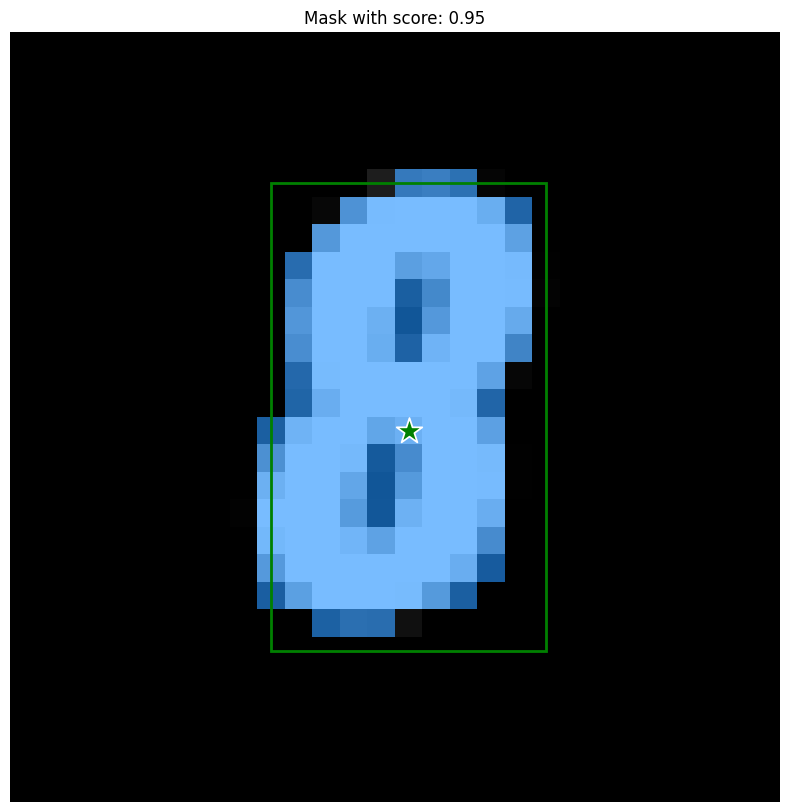

In [13]:
# Helper function to show mask and box
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='x', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

plt.figure(figsize=(10,10))
plt.imshow(image)

# Display the best mask (highest score)
# masks.shape is (num_masks, H, W)
# scores.shape is (num_masks,) -> we take the mask with the highest score
best_mask_idx = np.argmax(scores)
best_mask = masks[best_mask_idx]

show_mask(best_mask, plt.gca())
show_points(input_point, input_label, plt.gca())
# Note: SAM Predictor doesn't directly return bounding boxes for point prompts by default in `predict` output.
# The `masks` inherently define the segment, from which you can derive a bounding box.
# If you need boxes directly, you might need to process the mask to get its bounding box or use `predict_torch` for more options.

# To get a bounding box from the mask:
from skimage.measure import regionprops

if best_mask.any(): # Check if the mask is not empty
    props = regionprops(best_mask.astype(np.uint8))
    if props:
        min_row, min_col, max_row, max_col = props[0].bbox
        # SAM boxes are [xmin, ymin, xmax, ymax], regionprops are [min_row, min_col, max_row, max_col]
        # So we need to convert: [min_col, min_row, max_col, max_row]
        bbox_from_mask = [min_col, min_row, max_col, max_row]
        show_box(bbox_from_mask, plt.gca())

plt.title(f"Mask with score: {scores[best_mask_idx]:.2f}")
plt.axis('off')
plt.show()

In [14]:
from PIL import Image

# Assuming 'best_mask' is a boolean NumPy array from the previous steps
# Convert the boolean mask to uint8 with 0 for False and 255 for True
binary_mask_image = Image.fromarray(best_mask.astype(np.uint8) * 255)

# Define the output path for the binary mask image
output_mask_filepath = "/content/segmented_mask.png"

# Save the image
binary_mask_image.save(output_mask_filepath)

print(f"Binary mask exported to: {output_mask_filepath}")

Binary mask exported to: /content/segmented_mask.png


### Batch Processing Images with SAM

In [ ]:
output_sam_masks_dir = "/content/sam_masked_digits_v5"
output_bbox_file = "/content/sam_bounding_boxes.csv"
os.makedirs(output_sam_masks_dir, exist_ok=True)

bounding_box_data = []

print(f"Processing {len(image_files)} images with SAM...")

for i, img_path in enumerate(image_files):
    try:
        # Load image
        image_cv = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

        # Set image for predictor
        predictor.set_image(image_rgb)

        # Define a central point prompt for the digit
        # Adjusting input point to be more robust: image.shape is (H, W, C) for cv2 images
        input_point = np.array([[image_rgb.shape[0] // 2, image_rgb.shape[1] // 2]])
        input_label = np.array([1]) # 1 for foreground

        # Predict masks, scores, and logits
        masks, scores, _ = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True,
        )

        # Select the best mask (highest score)
        best_mask_idx = np.argmax(scores)
        best_mask = masks[best_mask_idx]

        # Derive bounding box from the best mask
        bbox_coords = [0, 0, 0, 0] # Initialize with default values
        if best_mask.any():
            from skimage.measure import regionprops
            props = regionprops(best_mask.astype(np.uint8))
            if props:
                min_row, min_col, max_row, max_col = props[0].bbox
                bbox_coords = [min_col, min_row, max_col, max_row]

        # Extract digit class and original filename
        digit_class = os.path.basename(os.path.dirname(img_path))
        original_filename = os.path.basename(img_path)

        # Save the binary mask
        class_output_dir = os.path.join(output_sam_masks_dir, digit_class)
        os.makedirs(class_output_dir, exist_ok=True)
        mask_filename = original_filename.replace('.png', '_sam_mask.png')
        mask_output_path = os.path.join(class_output_dir, mask_filename)
        # Invert the mask to ensure white digits on black background, as per user request.
        # SAM's best_mask typically represents foreground as True, so if it appeared inverted,
        # explicitly invert it before saving.
        Image.fromarray((~best_mask).astype(np.uint8) * 255).save(mask_output_path)

        # Store bounding box data
        bounding_box_data.append({
            'image_path': img_path,
            'digit_class': digit_class,
            'mask_path': mask_output_path,
            'bbox_xmin': bbox_coords[0],
            'bbox_ymin': bbox_coords[1],
            'bbox_xmax': bbox_coords[2],
            'bbox_ymax': bbox_coords[3]
        })

    except Exception as e:
        print(f"Could not process image {img_path} with SAM: {e}")

    if (i + 1) % 100 == 0: # Print progress every 100 images
        print(f"Processed {i + 1}/{len(image_files)} images...")

print("\nBatch processing with SAM complete.")

# Save bounding box data to a CSV file
import pandas as pd
bbox_df = pd.DataFrame(bounding_box_data)
bbox_df.to_csv(output_bbox_file, index=False)
print(f"Bounding box data saved to: {output_bbox_file}")

# Display first few rows of bounding box data
print("\nSample Bounding Box Data:")
display(bbox_df.head())

# Verify a few generated SAM masks
print(f"\nContents of a sample digit class folder in {output_sam_masks_dir}:")
sample_digit_class_path = os.path.join(output_sam_masks_dir, '0') # Assuming '0' is a digit class
if os.path.exists(sample_digit_class_path):
    print(os.listdir(sample_digit_class_path)[:5]) # Print first 5 mask filenames
else:
    print(f"Directory {sample_digit_class_path} not found.")

Processing 106920 images with SAM...
Processed 100/106920 images...
Processed 200/106920 images...
Processed 300/106920 images...
Processed 400/106920 images...
Processed 500/106920 images...
Processed 600/106920 images...
Processed 700/106920 images...
Processed 800/106920 images...
Processed 900/106920 images...
Processed 1000/106920 images...
Processed 1100/106920 images...
Processed 1200/106920 images...
Processed 1300/106920 images...
Processed 1400/106920 images...
Processed 1500/106920 images...
Processed 1600/106920 images...
Processed 1700/106920 images...
Processed 1800/106920 images...
Processed 1900/106920 images...
Processed 2000/106920 images...
Processed 2100/106920 images...
Processed 2200/106920 images...
Processed 2300/106920 images...
Processed 2400/106920 images...
Processed 2500/106920 images...
Processed 2600/106920 images...
Processed 2700/106920 images...
Processed 2800/106920 images...
Processed 2900/106920 images...
Processed 3000/106920 images...
Processed 31

### Evaluating Mask Quality

#### 1. Qualitative Evaluation: Visual Inspection

In [ ]:
import random
import matplotlib.pyplot as plt

def plot_masks_comparison(original_img_path, threshold_mask_path, sam_mask_path):
    original_img = Image.open(original_img_path).convert('RGB')
    threshold_mask = Image.open(threshold_mask_path).convert('L')
    sam_mask = Image.open(sam_mask_path).convert('L')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(threshold_mask, cmap='gray')
    axes[1].set_title("Thresholded Mask")
    axes[1].axis('off')

    axes[2].imshow(sam_mask, cmap='gray')
    axes[2].set_title("SAM Mask")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Select a few random images for visual inspection
sample_images = random.sample(image_files, min(5, len(image_files))) # Take up to 5 samples

print("Visual comparison of Original, Thresholded, and SAM Masks:")
for img_path in sample_images:
    digit_class = os.path.basename(os.path.dirname(img_path))
    original_filename = os.path.basename(img_path)

    # Construct paths for the corresponding masks
    threshold_mask_filename = original_filename.replace('.png', '_mask.png')
    threshold_mask_path = os.path.join(output_mask_dir, digit_class, threshold_mask_filename)

    sam_mask_filename = original_filename.replace('.png', '_sam_mask.png')
    sam_mask_path = os.path.join(output_sam_masks_dir, digit_class, sam_mask_filename)

    if os.path.exists(threshold_mask_path) and os.path.exists(sam_mask_path):
        print(f"Processing: {original_filename} (Class: {digit_class})")
        plot_masks_comparison(img_path, threshold_mask_path, sam_mask_path)
    else:
        print(f"Skipping {original_filename} as masks were not found.")

#### 2. Quantitative Evaluation: Intersection over Union (IoU)

In [ ]:
def calculate_iou(mask1, mask2):
    # Ensure masks are boolean or binary (0/1)
    mask1 = np.asarray(mask1).astype(bool)
    mask2 = np.asarray(mask2).astype(bool)

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0.0 # Avoid division by zero if both masks are entirely empty
    return intersection / union

# Calculate IoU for a subset of images
ious = []
num_iou_samples = 50 # Process a small number of images for demonstration
sample_for_iou = random.sample(image_files, min(num_iou_samples, len(image_files)))

print(f"Calculating IoU for {len(sample_for_iou)} samples...")
for img_path in sample_for_iou:
    digit_class = os.path.basename(os.path.dirname(img_path))
    original_filename = os.path.basename(img_path)

    threshold_mask_filename = original_filename.replace('.png', '_mask.png')
    threshold_mask_path = os.path.join(output_mask_dir, digit_class, threshold_mask_filename)

    sam_mask_filename = original_filename.replace('.png', '_sam_mask.png')
    sam_mask_path = os.path.join(output_sam_masks_dir, digit_class, sam_mask_filename)

    if os.path.exists(threshold_mask_path) and os.path.exists(sam_mask_path):
        mask_threshold = Image.open(threshold_mask_path).convert('L')
        mask_sam = Image.open(sam_mask_path).convert('L')

        iou_score = calculate_iou(mask_threshold, mask_sam)
        ious.append(iou_score)
    else:
        # print(f"Warning: Skipping {original_filename} for IoU calculation as masks were not found.")
        pass

if ious:
    average_iou = np.mean(ious)
    print(f"\nAverage IoU between Thresholded Masks and SAM Masks (over {len(ious)} samples): {average_iou:.4f}")
    plt.figure(figsize=(8, 5))
    plt.hist(ious, bins=20, edgecolor='black')
    plt.title('Distribution of IoU Scores')
    plt.xlabel('IoU Score')
    plt.ylabel('Number of Samples')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No IoU scores calculated. Ensure masks exist for the selected samples.")